## Pretraining the Text Autoencoder on a custom dataset

In [ ]:
!pip install torchinfo
!pip install clip
!pip install evaluate
!pip install rouge_score
!pip install nltk

In [ ]:
# @title Importing the necessary libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import CLIPProcessor, CLIPModel, RobertaModel, RobertaTokenizer, GPT2Tokenizer
import evaluate
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import tqdm
from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as FT
import math
from transformers import BertTokenizer
import gc
import random

from typing import Dict, Any, List, Optional, Tuple
import textwrap
from tqdm import tqdm
from src.utils.helper import parse_gdi_text, save_checkpoint_to_drive, load_checkpoint_from_drive, emb_dim, latent_dim, num_layers, max_seq_len, batch_size, dropout

# **Chapter 1: The data preparation**


---



## 1.1 Loading and saving data

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [ ]:

emb_dim = emb_dim
latent_dim = latent_dim
num_layers = num_layers
max_seq_len = max_seq_len
batch_size = batch_size
dropout = dropout

from transformers import get_cosine_schedule_with_warmup

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Now we load dataset from HuggingFace:

In [ ]:
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

In [ ]:
# @title CoT improvements toggles (added)



USE_FRAME_AWARE_GROUNDING = True
USE_CONTRASTIVE_ROI = True
USE_ENTITY_POOLING = True
USE_COT_TEXT = True


CONTRASTIVE_TAU = 0.07

In [ ]:
from src.models.text_autoencoder import TextTaskDataset
# =========================================================
# Tokenizers
# =========================================================

enc_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

dec_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
dec_tokenizer.pad_token = dec_tokenizer.eos_token
text_dataset = TextTaskDataset(
    dataset=train_dataset,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
    max_len=max_seq_len,
    target_max_len=max_seq_len,
)

text_dataloader = DataLoader(
    text_dataset,
    batch_size=batch_size,
    shuffle=True,
)


TextTaskDataset created with 44,199 frame-level samples.


In [ ]:
for batch in text_dataloader:
    print("enc_input_ids:", batch["enc_input_ids"].shape)
    print("enc_attention_mask:", batch["enc_attention_mask"].shape)
    print("target_ids:", batch["target_ids"].shape)
    print("target_attention_mask:", batch["target_attention_mask"].shape)
    print("labels:", batch["labels"].shape)
    print()
    print("Example description:")
    print(batch["description"][0])
    break

enc_input_ids: torch.Size([16, 120])
enc_attention_mask: torch.Size([16, 120])
target_ids: torch.Size([16, 120])
target_attention_mask: torch.Size([16, 120])
labels: torch.Size([16, 120])

Example description:
The office was abuzz with activity as Mike , Olivia , and Sam gathered around, discussing the situation. Mike spoke up, "We need to find a way to work together again. The team is depending on us." Olivia and Sam nodded in agreement, their expressions reflecting the seriousness of the situation. The bright office lighting cast a harsh light on the faces of the team, highlighting the gravity of the moment.


In [ ]:
print(train_dataset[0].keys())

dict_keys(['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'])


## 3.1 Initialization and setup

In [ ]:
import importlib
import src.models.text_autoencoder as text_autoencoder_module

importlib.reload(text_autoencoder_module)

from src.models.text_autoencoder import (
    RobertaEncoder,
    TransformerDecoder,
    Seq2Seq,
    SinusoidalPositionalEncoding,
)

In [ ]:
from transformers import RobertaModel, EncoderDecoderModel, AutoConfig
# @title Initializing the Roberta model
from src.models.text_autoencoder import RobertaEncoder, TransformerDecoder, Seq2Seq, SinusoidalPositionalEncoding
torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dec_tokenizer.pad_token = dec_tokenizer.eos_token      # GPT-2 has no pad token

text_autoencoder = Seq2Seq(
    encoder_name="roberta-base",
    decoder_name="gpt2",
    unfreeze_encoder_layers=6,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
).to(device)

trainable = sum(p.numel() for p in text_autoencoder.parameters() if p.requires_grad)
total     = sum(p.numel() for p in text_autoencoder.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: gpt2
Key                                                 | Status  | 
----------------------------------------------------+---------+-
transformer.h.{0...11}.crossattention.q_attn.bias   | MISSING | 
transformer.h.{0...11}.ln_cross_attn.weight         | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.weight | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.weight | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.bias   | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.bias   | MISSING | 
transformer.h.{0...11}.crossattention.q_attn.weight | MISSING | 
transformer.h.{0...11}.ln_cross_attn.bias           | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 195,333,888
Total params:     277,452,288


In [ ]:
enc_len = min(max_seq_len, 512)        # RoBERTa caps at 512
dec_len = 256                          # target length (match your max_target_len)

dummy_input  = torch.randint(0, enc_tokenizer.vocab_size, (batch_size, enc_len)).to(device)
dummy_mask   = torch.ones((batch_size, enc_len), dtype=torch.long).to(device)   # all valid
dummy_labels = torch.randint(0, dec_tokenizer.vocab_size, (batch_size, dec_len)).to(device)

print("===== RoBERTa2GPT2 Seq2Seq Summary =====")
summary(
    text_autoencoder,
    input_data=(dummy_input, dummy_mask, dummy_labels),   # input_ids, attention_mask, labels
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3,
)

===== RoBERTa2GPT2 Seq2Seq Summary =====


/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Trainable
Seq2Seq                                                           [16, 120]                 [16, 120, 768]            --                        Partial
├─EncoderDecoderModel: 1-1                                        --                        [16, 120, 768]            --                        Partial
│    └─RobertaModel: 2-1                                          --                        [16, 768]                 --                        Partial
│    │    └─RobertaEmbeddings: 3-1                                --                        [16, 120, 768]            (39,000,576)              False
│    │    └─RobertaEncoder: 3-2                                   [16, 120, 768]            [16, 120, 768]            85,054,464                Partial
│    │    └─RobertaPooler: 3-3                                    [16, 120, 768]        

## 3.2 Training loops

✓ Checkpoint loaded from Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 6)
Resuming from epoch 6 | best loss so far: 0.76741


Epoch 7/16: 100%|██████████| 2763/2763 [17:54<00:00,  2.57it/s, ce=0.7595, total=0.7595, enc_lr=6.71e-06, dec_lr=6.71e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 7
CE Loss     : 0.75988
Div Loss    : 0.00000
Total Loss  : 0.75988

  EPOCH 7 EVALUATION


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled over The old mansionAs footsteps echoed past the empty corridors. thunder echoed over the ancient mansion as whispers echoed throughThe empty halls of.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their next tentative calls calling.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.080
river_fish ↔ mansion : 0.059
river_fish ↔ forest : 0.091
river_fish ↔ desert : 0.069
space ↔ mansion : 0.148
space ↔ forest : 0.069
space ↔ desert : 0.083
mansion ↔ forest : 0.143
mansion ↔ desert : 0.061
forest ↔ desert : 0.061

Average overlap: 0.086

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 7)
  ✓ new best
✓ Epoch 7 log appended to Drive: /content/drive/MyDrive/DL_Checkpoints/training_text_log.txt


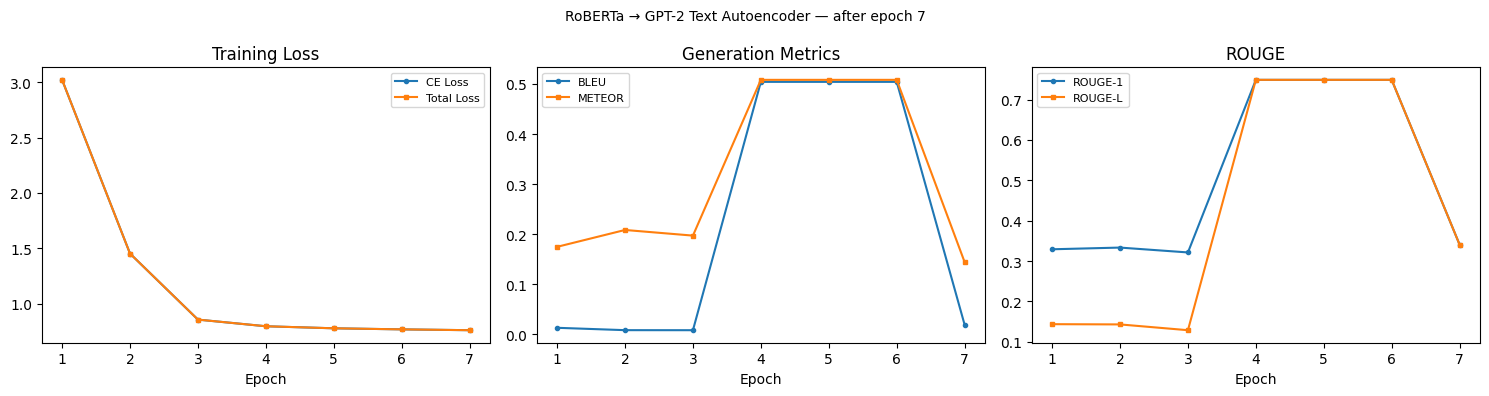

Epoch 8/16: 100%|██████████| 2763/2763 [18:10<00:00,  2.53it/s, ce=0.7561, total=0.7561, enc_lr=5.68e-06, dec_lr=5.68e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 8
CE Loss     : 0.75640
Div Loss    : 0.00000
Total Loss  : 0.75640

  EPOCH 8 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space. The abandoned space Station drifted silently into the darkness, darkness of dark space. abandoned spaces station drifted unnoticed through the dark of deep Space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder echoed over the ancient halls as footsteps echoing through the emptiness halls. footsteps echoed over this old mansionAs footsteps echoed into the empty corrido



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the Ancient trees as bird began their most tentative cries. Birds began clinging to the old trees, birds began Their first tentative call.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction. Something moved for yards in any way.

Pairwise overlaps:

river_fish ↔ space : 0.067
river_fish ↔ mansion : 0.056
river_fish ↔ forest : 0.083
river_fish ↔ desert : 0.062
space ↔ mansion : 0.118
space ↔ forest : 0.083
space ↔ desert : 0.097
mansion ↔ forest : 0.125
mansion ↔ desert : 0.053
forest ↔ desert : 0.079

Average overlap: 0.082

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 8)
  ✓ new bes

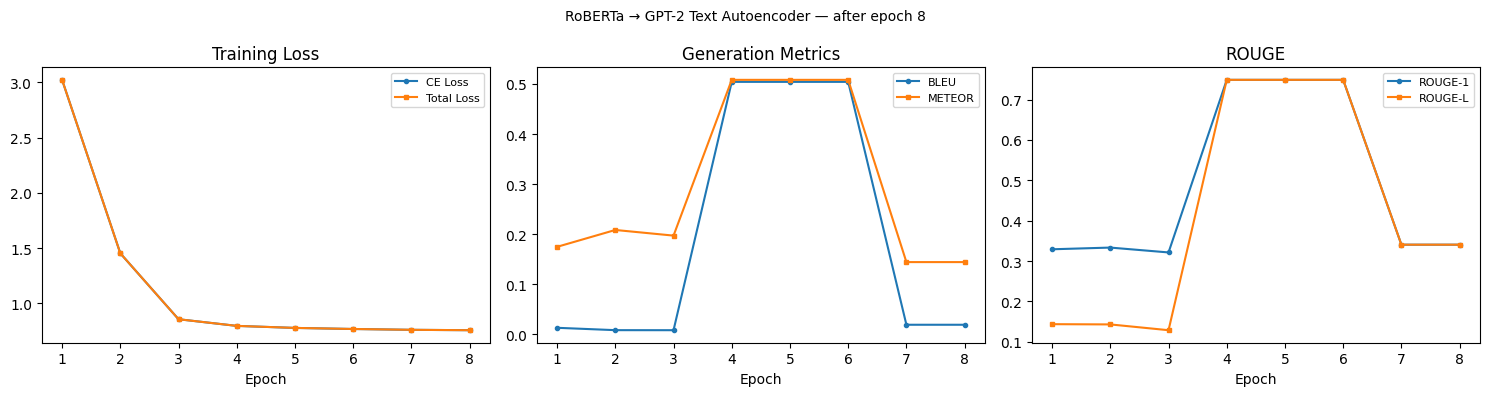

Epoch 9/16: 100%|██████████| 2763/2763 [18:18<00:00,  2.51it/s, ce=0.7510, total=0.7510, enc_lr=4.62e-06, dec_lr=4.62e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 9
CE Loss     : 0.75386
Div Loss    : 0.00000
Total Loss  : 0.75386

  EPOCH 9 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space. The abandoned space Station drifted silently into the darkness, deep of deep Space space. abandoned spaces station drifted quietly through the dark space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. footsteps echoed around the old halls as footsteps echoing through the emptiness halls. Thunder rolled under the old Mansion as footsteps echo through the filled halls.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their most tentative cries. Tonight morning mist clinging to the Ancient trees as Birds began their First tentativ

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction. nothing moved For miles in anyone direction.

Pairwise overlaps:

river_fish ↔ space : 0.067
river_fish ↔ mansion : 0.094
river_fish ↔ forest : 0.083
river_fish ↔ desert : 0.103
space ↔ mansion : 0.094
space ↔ forest : 0.054
space ↔ desert : 0.103
mansion ↔ forest : 0.105
mansion ↔ desert : 0.061
forest ↔ desert : 0.054

Average overlap: 0.082

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 9)


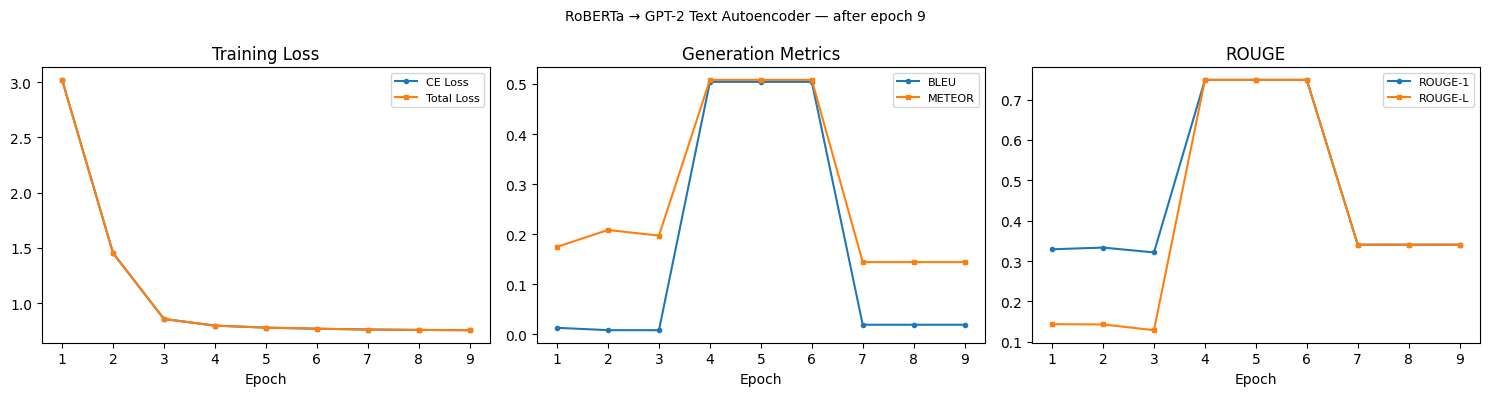

Epoch 10/16: 100%|██████████| 2763/2763 [18:22<00:00,  2.51it/s, ce=0.7530, total=0.7530, enc_lr=3.57e-06, dec_lr=3.57e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 10
CE Loss     : 0.75212
Div Loss    : 0.00000
Total Loss  : 0.75212

  EPOCH 10 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled under the old Mansion as footsteps echoing through the emptiness halls. thunder rolled over The old mansionAs footsteps echoed over the empty corridors, 



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the Ancient trees as bird began their most tentative cries.Morning mist clinging to the old trees as Birds began their First tentative calls,.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.080
river_fish ↔ mansion : 0.088
river_fish ↔ forest : 0.086
river_fish ↔ desert : 0.107
space ↔ mansion : 0.103
space ↔ forest : 0.065
space ↔ desert : 0.083
mansion ↔ forest : 0.132
mansion ↔ desert : 0.091
forest ↔ desert : 0.088

Average overlap: 0.092

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 10)
  ✓ new best
✓ Epoch 10 log appended to Driv

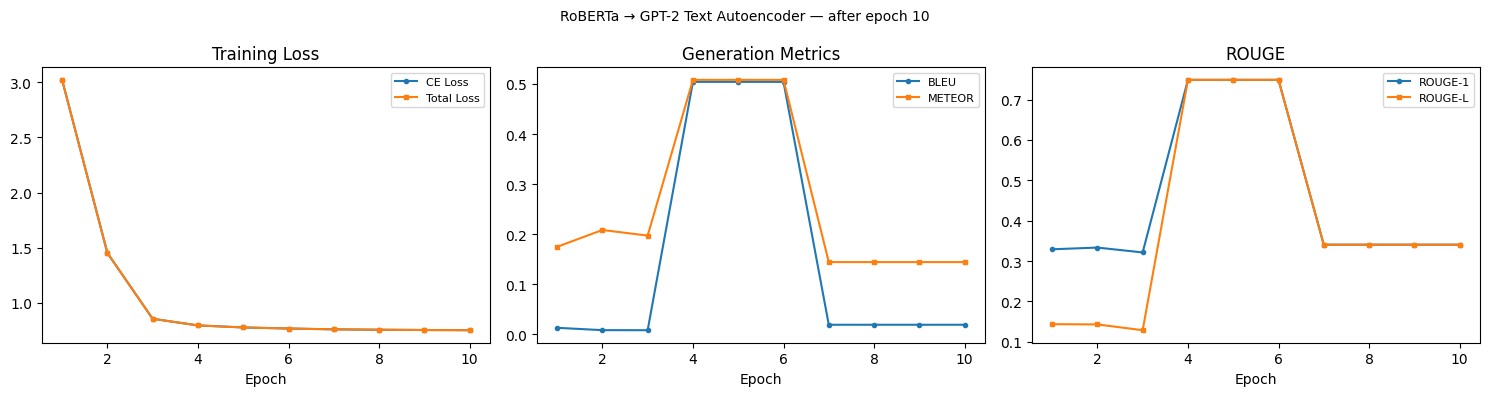

Epoch 11/16: 100%|██████████| 2763/2763 [18:22<00:00,  2.51it/s, ce=0.7495, total=0.7495, enc_lr=2.59e-06, dec_lr=2.59e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 11
CE Loss     : 0.75076
Div Loss    : 0.00000
Total Loss  : 0.75076

  EPOCH 11 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space. The abandoned space Station drifted silently into the darkness to deep space, deep darkness. abandoned alien space station drift silently through this darkness.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder echoed over the empty corridors. footsteps echoed around the empty hall. Thunder rolled under the old halls as footsteps echoing through the emptiness halls.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the Ancient trees as bird began their most tentative cries. Tonight morning mist clinging to the old trees clings to these ancient trees.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.065
river_fish ↔ mansion : 0.094
river_fish ↔ forest : 0.081
river_fish ↔ desert : 0.107
space ↔ mansion : 0.091
space ↔ forest : 0.079
space ↔ desert : 0.103
mansion ↔ forest : 0.103
mansion ↔ desert : 0.062
forest ↔ desert : 0.054

Average overlap: 0.084

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 11)
  ✓ new best
✓ Epoch 11 log appended to Drive: /c

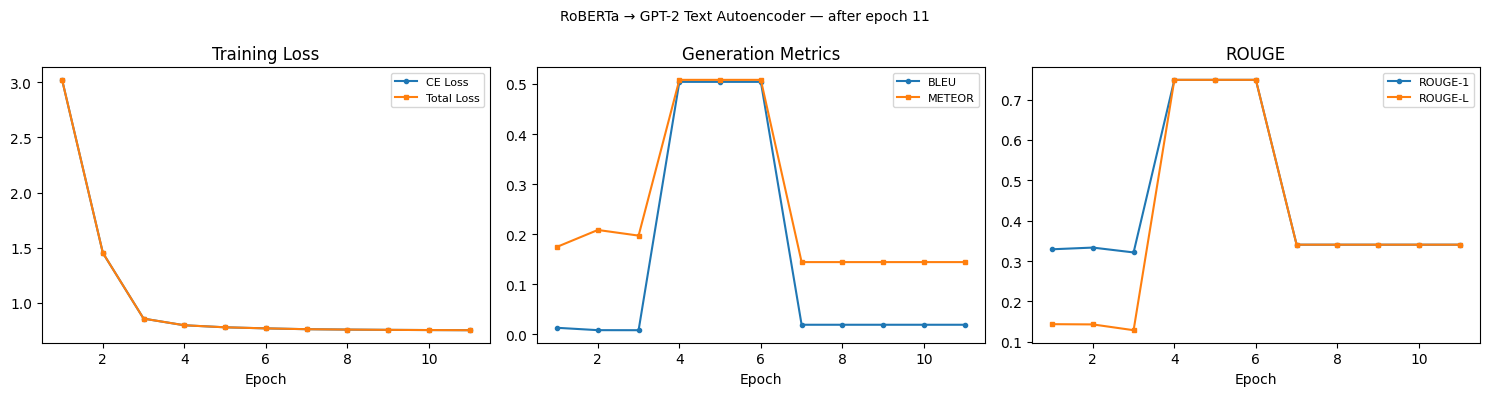

Epoch 12/16: 100%|██████████| 2763/2763 [18:27<00:00,  2.49it/s, ce=0.7482, total=0.7482, enc_lr=1.71e-06, dec_lr=1.71e-05]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 12
CE Loss     : 0.74979
Div Loss    : 0.00000
Total Loss  : 0.74979

  EPOCH 12 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled under the old Mansion as footsteps echoing through the emptiness halls. thunder rolled over The old mansionAs footsteps echoed over the empty corridors.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the Ancient trees as bird began their most tentative cries.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.095
river_fish ↔ mansion : 0.071
river_fish ↔ forest : 0.107
river_fish ↔ desert : 0.080
space ↔ mansion : 0.115
space ↔ forest : 0.071
space ↔ desert : 0.083
mansion ↔ forest : 0.088
mansion ↔ desert : 0.065
forest ↔ desert : 0.062

Average overlap: 0.084

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 12)
  ✓ new best
✓ Epoch 12 log appended to Drive: /content/drive/MyDrive/DL_Checkpoints/training_text_log.txt


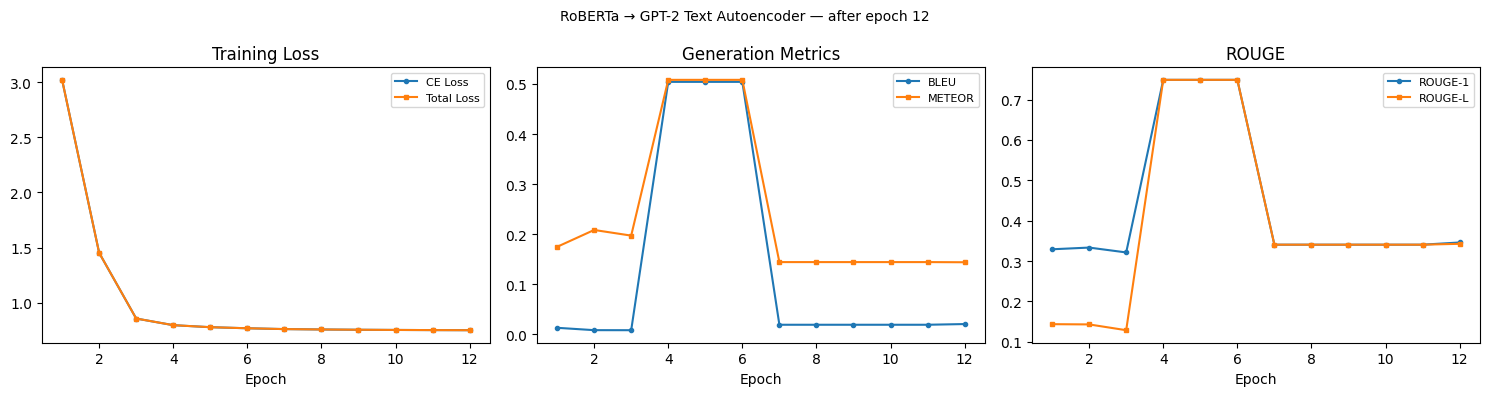

Epoch 13/16: 100%|██████████| 2763/2763 [18:36<00:00,  2.48it/s, ce=0.7480, total=0.7480, enc_lr=9.90e-07, dec_lr=9.90e-06]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 13
CE Loss     : 0.74909
Div Loss    : 0.00000
Total Loss  : 0.74909

  EPOCH 13 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  Thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled under the old Mansion as footsteps echoing through the emptiness halls. thunder rolled over The old mansionAs footsteps rolled over this empty halls, a t



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their most tentative cries.Morning mist clinging to the Ancient trees clung onto the ancient tree trees.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.080
river_fish ↔ mansion : 0.088
river_fish ↔ forest : 0.083
river_fish ↔ desert : 0.107
space ↔ mansion : 0.103
space ↔ forest : 0.062
space ↔ desert : 0.083
mansion ↔ forest : 0.128
mansion ↔ desert : 0.091
forest ↔ desert : 0.056

Average overlap: 0.088

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 13)
  ✓ new best
✓ Epoch 13 log appended to Drive: /conten

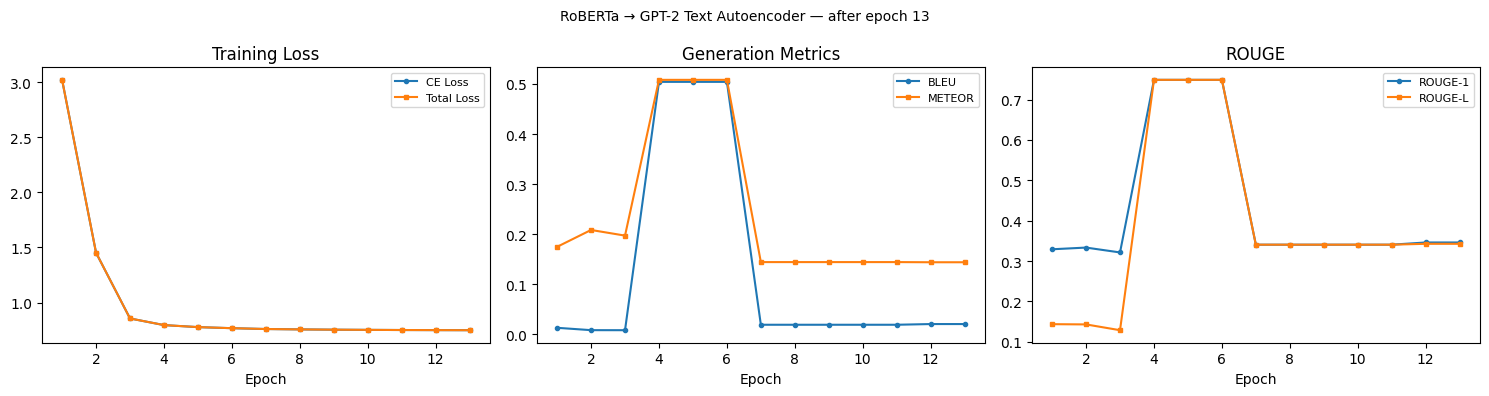

Epoch 14/16: 100%|██████████| 2763/2763 [18:37<00:00,  2.47it/s, ce=0.7480, total=0.7480, enc_lr=4.49e-07, dec_lr=4.49e-06]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 14
CE Loss     : 0.74864
Div Loss    : 0.00000
Total Loss  : 0.74864

  EPOCH 14 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled under the old Mansion as footsteps echoing through the emptiness halls. thunder rolling over the ancient halls as footsteps echo through the filled halls



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their most tentative cries.Morning mist clinging to the Ancient trees clung To the ancient tree calls.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.095
river_fish ↔ mansion : 0.067
river_fish ↔ forest : 0.097
river_fish ↔ desert : 0.080
space ↔ mansion : 0.107
space ↔ forest : 0.065
space ↔ desert : 0.083
mansion ↔ forest : 0.135
mansion ↔ desert : 0.061
forest ↔ desert : 0.057

Average overlap: 0.085

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 14)
  ✓ new best
✓ Epoch 14 log appended to Drive: /content/

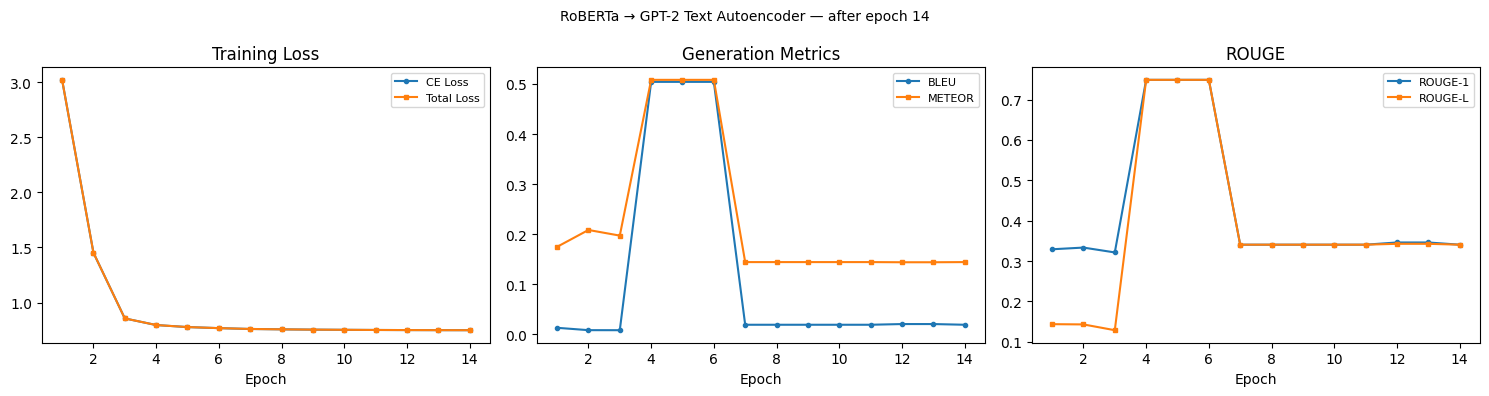

Epoch 15/16: 100%|██████████| 2763/2763 [18:37<00:00,  2.47it/s, ce=0.7480, total=0.7480, enc_lr=1.13e-07, dec_lr=1.13e-06]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 15
CE Loss     : 0.74841
Div Loss    : 0.00000
Total Loss  : 0.74841

  EPOCH 15 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled over The old mansionAs footsteps echoed around the empty corridors. Thunder rolling over the ancient halls as footsteps echoing through the emptiness hal



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their most tentative cries.Morning mist clinging to the Ancient trees clung To the ancient tree calls.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.080
river_fish ↔ mansion : 0.059
river_fish ↔ forest : 0.086
river_fish ↔ desert : 0.107
space ↔ mansion : 0.107
space ↔ forest : 0.065
space ↔ desert : 0.083
mansion ↔ forest : 0.135
mansion ↔ desert : 0.061
forest ↔ desert : 0.057

Average overlap: 0.084

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 15)
  ✓ new best
✓ Epoch 15 log appended to Drive: /content/

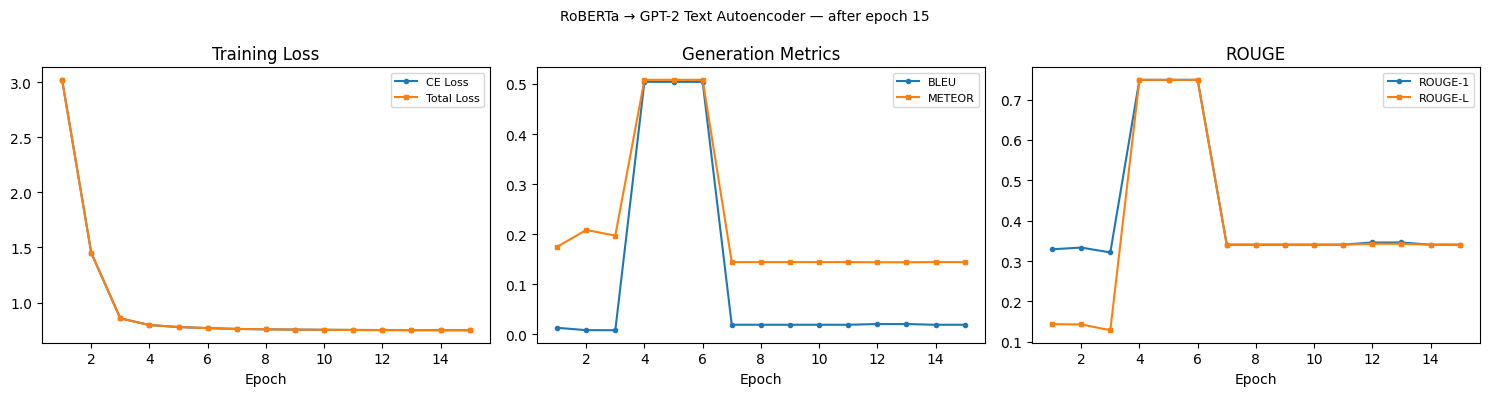

Epoch 16/16: 100%|██████████| 2763/2763 [18:48<00:00,  2.45it/s, ce=0.7493, total=0.7493, enc_lr=0.00e+00, dec_lr=0.00e+00]
[transformers] Both `max_new_tokens` (=160) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Epoch 16
CE Loss     : 0.74831
Div Loss    : 0.00000
Total Loss  : 0.74831

  EPOCH 16 EVALUATION


[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REFERENCE:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed

GENERATED:
The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John , he

[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[space]
PROMPT : The abandoned space station drifted silently through the darkness of deep space.
OUTPUT : The abandoned space station drifted silently through the darkness of deep space.



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[mansion]
PROMPT : Thunder rolled over the old mansion as footsteps echoed through the empty halls.
OUTPUT :  thunder rolled over the old mansion as footsteps echoed through the empty halls. Thunder rolled over The old mansionAs footsteps echoed around the empty corridors. Thunder rolling over the ancient halls as footsteps echoing through the emptiness hal



[transformers] Both `max_new_tokens` (=80) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[forest]
PROMPT : Morning mist clung to the ancient trees as birds began their first tentative calls.
OUTPUT : Morning mist clung to the ancient trees as birds began their first tentative calls. morning mist clanged to the old trees as bird began their most tentative cries.Morning mist clinging to the Ancient trees clung To the ancient tree calls.

[desert]
PROMPT : The sun hammered the cracked earth, and nothing moved for miles in any direction.
OUTPUT : The sun hammered the cracked earth, and nothing moved for miles in any direction.

Pairwise overlaps:

river_fish ↔ space : 0.080
river_fish ↔ mansion : 0.059
river_fish ↔ forest : 0.086
river_fish ↔ desert : 0.107
space ↔ mansion : 0.107
space ↔ forest : 0.065
space ↔ desert : 0.083
mansion ↔ forest : 0.135
mansion ↔ desert : 0.061
forest ↔ desert : 0.057

Average overlap: 0.084

✓ Checkpoint saved to Drive: /content/drive/MyDrive/DL_Checkpoints/text_autoencoder.pth  (epoch 16)
  ✓ new best
✓ Epoch 16 log appended to Drive: /content/

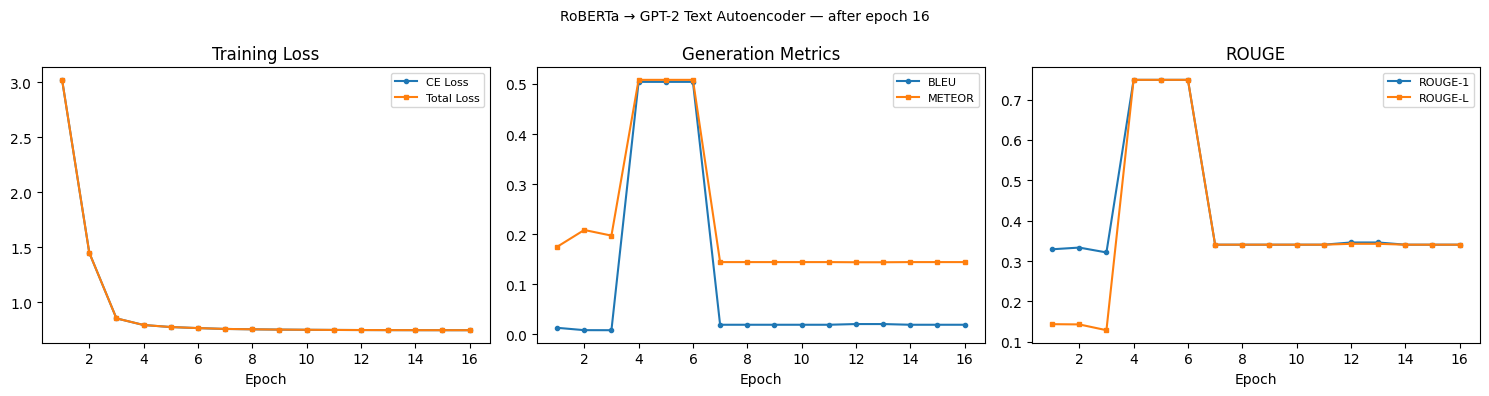


✓ Training complete.


In [ ]:
from src.training.train_text import (
    ContrastiveDiversityLoss,
    EarlyStopping,
    build_optimizer,
    build_scheduler,
    train_text_autoencoder,
)

# =========================================================
# FIXED EVALUATION PROMPTS
# =========================================================
EVAL_PROMPT = (
    "The night was thick with tension as Officer Smith stood in the heart of the military base. The air carried with it the weight of an impending decision, a decision that would alter the course of history. Officer Smith looked over the shoulder of Soldier John, who stood at attention, his military uniform a symbol of dedication and duty. The officer thought, “How did it come to this? How did the line between us and them become so blurred?” As he glanced at Soldier John, he sighed, knowing he needed to make a choice, one that could either save or condemn many lives."
"The scene shifted as Officer Smith sent Soldier John and the other soldiers into the city. They aimed their weapons, ready for any threat that might come their way. The city buildings loomed in the background, casting long shadows over the streets. Soldier John felt a mix of anxiety and determination. He thought, “We’ve trained for this, but nothing could have prepared us for what’s to come."
 "As Soldier Rachel and Soldier John advanced through the urban streets, she spoke to him, her voice barely above a whisper. “Keep your guard up, John. They could be anywhere.” He nodded, his weapon steady as he scanned the area for any signs of danger. The silence was deafening, and he felt a creeping sense of unease. Who were they really fighting? And what did it all mean?"

"The tension escalated as Anon Leader emerged from the shadows, the mask covering his face, symbolizing the resistance. Anon Leader led a group of masked individuals, their presence a stark contrast to the soldiers in uniform. The urban buildings watched silently as the two groups faced off. Anon Leader spoke with a determined tone, “We won’t back down, not until our voices are heard.” The soldiers, caught in the moment, wondered what this meant for their mission."
"The confrontation continued as Anon Leader stood among the soldiers. The air was thick with tension, and they tried to decipher the meaning behind the masked figure. Anon Leader spoke again, “We are not your enemies. We are the voice of the people.” The soldiers remained silent, unsure of how to respond."

"As Soldier Alex, Soldier John, and Soldier Rachel aimed their weapons, John questioned himself, “Are we doing the right thing?” Rachel glanced at John, sensing his unease. “We have orders, John. We can’t question them now.” But as Anon Leader stood unwavering, John felt a growing sense of doubt. Was there more to this than just following orders?"

"The soldiers, including Soldier Taylor and Soldier Rita, aimed their weapons, their focus unwavering. The tension was palpable as Soldier John, Soldier Alex, and Soldier Greg prepared for the clash that seemed inevitable. But as John looked into the eyes of the masked figures, he realized that these were ordinary people, fighting for a cause they believed in. The line between right and wrong blurred, and John felt a sense of moral conflict."

)

EVAL_REFERENCE = EVAL_PROMPT

DIVERSITY_PROMPTS = {
    "river_fish":   "The fish swam against the powerful river current beneath bright morning sunlight.",
    "space":        "The abandoned space station drifted silently through the darkness of deep space.",
    "mansion":      "Thunder rolled over the old mansion as footsteps echoed through the empty halls.",
    "forest":       "Morning mist clung to the ancient trees as birds began their first tentative calls.",
    "desert":       "The sun hammered the cracked earth, and nothing moved for miles in any direction.",
}

# =========================================================
# TRAINING CONFIG
# =========================================================

N_EPOCHS = 16

LR_DECODER = 1e-4
LR_ENCODER = 1e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

LABEL_SMOOTHING = 0.05

W_CE = 1.0


W_DIVERSITY = 0.0

checkpoint_filename = "text_autoencoder.pth"

optimizer = build_optimizer(
    text_autoencoder,
    lr_encoder=LR_ENCODER,
    lr_decoder=LR_DECODER,
    weight_decay=WEIGHT_DECAY,
)

scheduler = build_scheduler(
    optimizer=optimizer,
    dataloader_len=len(text_dataloader),
    n_epochs=N_EPOCHS,
    warmup_ratio=0.08,
)

history = train_text_autoencoder(
    model=text_autoencoder,
    dataloader=text_dataloader,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    n_epochs=N_EPOCHS,
    checkpoint_filename=checkpoint_filename,
    eval_prompt=EVAL_PROMPT,
    eval_reference=EVAL_REFERENCE,
    diversity_prompts=DIVERSITY_PROMPTS,
    max_grad_norm=MAX_GRAD_NORM,
    label_smoothing=LABEL_SMOOTHING,
    ce_weight=W_CE,
    diversity_weight=W_DIVERSITY,
    resume=True,
    plot_every=1,
)

In [ ]:
test_text_dataset = TextTaskDataset(
    dataset=test_dataset,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
    max_len=max_seq_len,
    target_max_len=max_seq_len,
)

test_text_dataloader = DataLoader(
    test_text_dataset,
    batch_size=batch_size,
    shuffle=False,
)

TextTaskDataset created with 7,758 frame-level samples.


In [ ]:
# =========================================================
# Evaluate test CE loss
# =========================================================

@torch.no_grad()
def evaluate_test_loss(model, dataloader, device):
    model.eval()

    losses = []

    for batch in tqdm(dataloader, desc="Evaluating test CE loss"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        decoder_attention_mask = None
        if "target_attention_mask" in batch:
            decoder_attention_mask = batch["target_attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            decoder_attention_mask=decoder_attention_mask,
        )

        losses.append(outputs.loss.item())

    avg_loss = sum(losses) / max(len(losses), 1)

    model.train()
    return avg_loss


test_ce_loss = evaluate_test_loss(
    model=text_autoencoder,
    dataloader=test_text_dataloader,
    device=device,
)

print(f"TEST CE Loss: {test_ce_loss:.6f}")

Evaluating test CE loss: 100%|██████████| 485/485 [02:41<00:00,  3.01it/s]

TEST CE Loss: 0.077909


In [ ]:
# =========================================================
# Evaluate reconstruction generation metrics on test samples
# =========================================================
from src.training.train_text import generate_text, compute_metrics
@torch.no_grad()
def evaluate_test_generation_metrics(
    model,
    test_text_dataset,
    enc_tokenizer,
    dec_tokenizer,
    device,
    num_samples=50,
    max_new_tokens=220,
    print_examples=5,
):
    model.eval()

    n = min(num_samples, len(test_text_dataset))
    results = []
    rows = []

    for i in tqdm(range(n), desc="Evaluating test generation metrics"):
        reference = test_text_dataset.samples[i]["description"]

        generated = generate_text(
            model=model,
            enc_tokenizer=enc_tokenizer,
            dec_tokenizer=dec_tokenizer,
            prompt=reference,
            device=device,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=3,
        )

        metrics = compute_metrics(
            hypothesis=generated,
            reference=reference,
        )

        results.append(metrics)

        rows.append(
            {
                "sample_id": i,
                "reference": reference,
                "generated": generated,
                "bleu": metrics["bleu"],
                "meteor": metrics["meteor"],
                "rouge1": metrics["rouge1"],
                "rouge2": metrics["rouge2"],
                "rougeL": metrics["rougeL"],
            }
        )

        if i < print_examples:
            print("=" * 100)
            print(f"TEST SAMPLE {i + 1}")
            print("-" * 100)
            print("REFERENCE:")
            print(reference[:1000])
            print("\nGENERATED:")
            print(generated[:1000])
            print("\nMETRICS:")
            print(metrics)

    avg_metrics = {
        key: sum(m[key] for m in results) / max(len(results), 1)
        for key in results[0].keys()
    }

    df = pd.DataFrame(rows)

    print("=" * 100)
    print("AVERAGE TEST GENERATION METRICS")
    print("=" * 100)
    for k, v in avg_metrics.items():
        print(f"{k}: {v:.6f}")

    model.train()
    return avg_metrics, df


test_avg_metrics, test_results_df = evaluate_test_generation_metrics(
    model=text_autoencoder,
    test_text_dataset=test_text_dataset,
    enc_tokenizer=enc_tokenizer,
    dec_tokenizer=dec_tokenizer,
    device=device,
    num_samples=5,
    max_new_tokens=220,
    print_examples=5,
)

In [ ]:
print(f"TEST CE Loss : {test_ce_loss:.6f}")
print(f"TEST BLEU    : {test_avg_metrics['bleu']:.6f}")
print(f"TEST ROUGE-1 : {test_avg_metrics['rouge1']:.6f}")
print(f"TEST ROUGE-2 : {test_avg_metrics['rouge2']:.6f}")
print(f"TEST ROUGE-L : {test_avg_metrics['rougeL']:.6f}")
print(f"TEST METEOR  : {test_avg_metrics['meteor']:.6f}")